In [215]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

data = pd.read_csv('datasets\sber (1).csv', delimiter=';')
data = data[:180]
data

,<DATE>,<OPEN>,<HIGH>,<LOW>,<CLOSE>,<VOL>
0,21224,237.09,238.70,234.32,235.17,45050170
1,31224,235.29,235.97,230.26,230.80,45313800
2,41224,231.05,233.79,224.30,224.55,72374990
3,51224,224.60,233.75,222.82,233.48,86902200
4,61224,233.63,238.25,231.52,237.84,81003410
...,...,...,...,...,...,...
175,50725,319.50,320.60,319.50,319.55,671870
176,60725,319.65,319.70,319.29,319.37,416040
177,70725,319.38,319.94,312.82,313.50,29913000
178,80725,313.34,315.31,309.60,309.71,25532140


In [216]:
data.to_string()

'     <DATE>  <OPEN>  <HIGH>   <LOW>  <CLOSE>      <VOL>\n0     21224  237.09  238.70  234.32   235.17   45050170\n1     31224  235.29  235.97  230.26   230.80   45313800\n2     41224  231.05  233.79  224.30   224.55   72374990\n3     51224  224.60  233.75  222.82   233.48   86902200\n4     61224  233.63  238.25  231.52   237.84   81003410\n5     91224  239.27  240.51  236.75   237.29   52314320\n6    101224  238.00  238.01  230.65   230.82   58548350\n7    111224  230.50  234.39  229.22   234.19   64817940\n8    121224  234.00  235.95  228.52   229.02   59118900\n9    131224  228.89  231.33  227.85   228.70   46091280\n10   161224  228.60  229.05  224.38   225.53   54519260\n11   171224  225.58  227.49  223.72   226.50   45827690\n12   181224  226.72  230.80  224.33   230.15   58002020\n13   191224  230.17  234.99  227.71   229.00  123831990\n14   201224  229.32  258.98  228.03   257.60  235163880\n15   231224  260.00  270.00  256.51   264.90  162588610\n16   241224  264.93  266.79  2

In [217]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   <DATE>   180 non-null    int64  
 1   <OPEN>   180 non-null    float64
 2   <HIGH>   180 non-null    float64
 3   <LOW>    180 non-null    float64
 4   <CLOSE>  180 non-null    float64
 5   <VOL>    180 non-null    int64  
dtypes: float64(4), int64(2)
memory usage: 8.6 KB


In [218]:
data.isna().sum()

<DATE>     0
<OPEN>     0
<HIGH>     0
<LOW>      0
<CLOSE>    0
<VOL>      0
dtype: int64

In [219]:
data['<DATE>'] = data['<DATE>'].astype(str).str.zfill(6)
data['<DATE>'] = pd.to_datetime(data['<DATE>'], format='%d%m%y')
data.set_index('<DATE>', inplace=True)
data.rename(columns={'<OPEN>': 'Open'}, inplace=True)
data.rename(columns={'<HIGH>': 'High'}, inplace=True)
data.rename(columns={'<LOW>': 'Low'}, inplace=True)
data.rename(columns={'<CLOSE>': 'Close'}, inplace=True)
data.rename(columns={'<VOL>': 'Volume'}, inplace=True)
data

,Open,High,Low,Close,Volume
<DATE>,,,,,
2024-12-02,237.09,238.70,234.32,235.17,45050170
2024-12-03,235.29,235.97,230.26,230.80,45313800
2024-12-04,231.05,233.79,224.30,224.55,72374990
2024-12-05,224.60,233.75,222.82,233.48,86902200
2024-12-06,233.63,238.25,231.52,237.84,81003410
...,...,...,...,...,...
2025-07-05,319.50,320.60,319.50,319.55,671870
2025-07-06,319.65,319.70,319.29,319.37,416040
2025-07-07,319.38,319.94,312.82,313.50,29913000


In [220]:
data.describe().round(2)

,Open,High,Low,Close,Volume
count,180.00,180.00,180.00,180.00,1.800000e+02
mean,297.25,300.34,294.18,297.36,4.309172e+07
std,24.78,24.16,24.93,24.34,3.397953e+07
min,224.60,227.49,222.82,224.55,4.160400e+05
25%,283.85,286.83,280.25,283.37,2.173937e+07
50%,306.44,309.59,302.79,306.88,3.902681e+07
75%,314.00,316.51,311.27,313.55,5.395994e+07
max,326.19,329.77,323.82,326.02,2.351639e+08


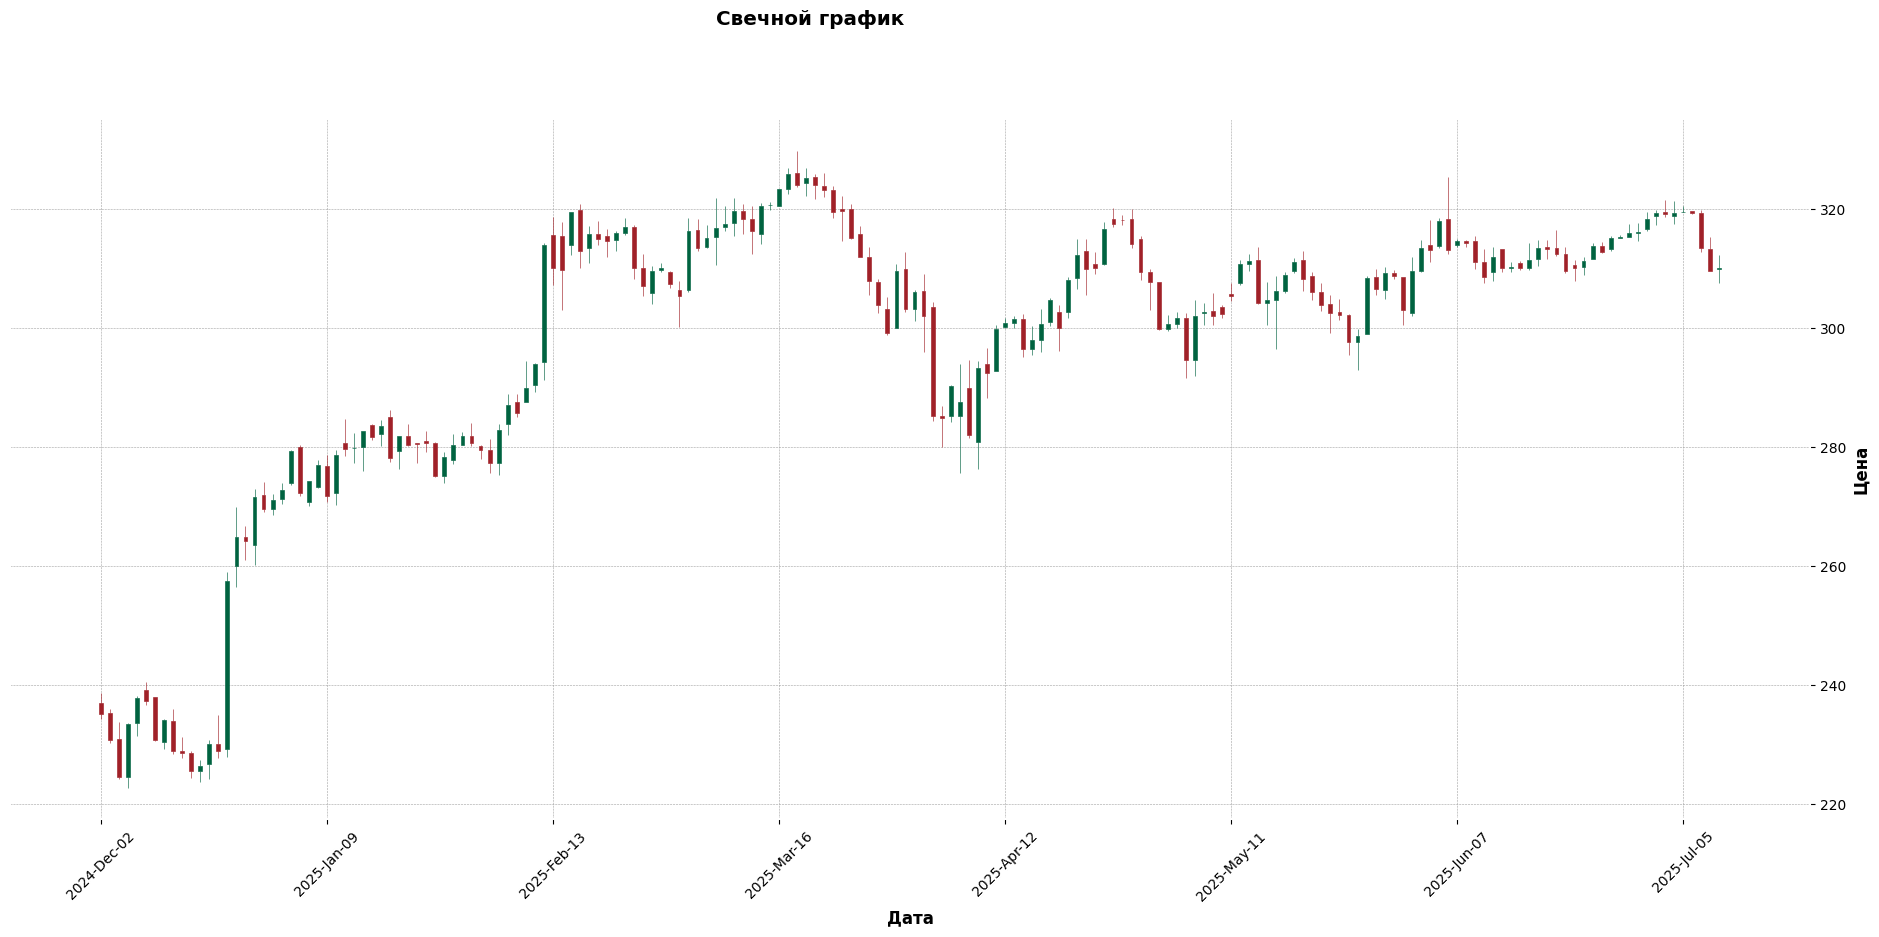

In [221]:
import mplfinance as mf

mf.plot(data, type='candle', style='charles', title='Свечной график',figsize=(25, 10), xlabel='Дата', ylabel='Цена')

C:\Users\Admin\AppData\Local\Temp\ipykernel_13156\2869445820.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data['Trend'] = ['Uptrend' if data['Close'][i] > data['MAn'][i] else 'Downtrend' for i in range(len(data))]


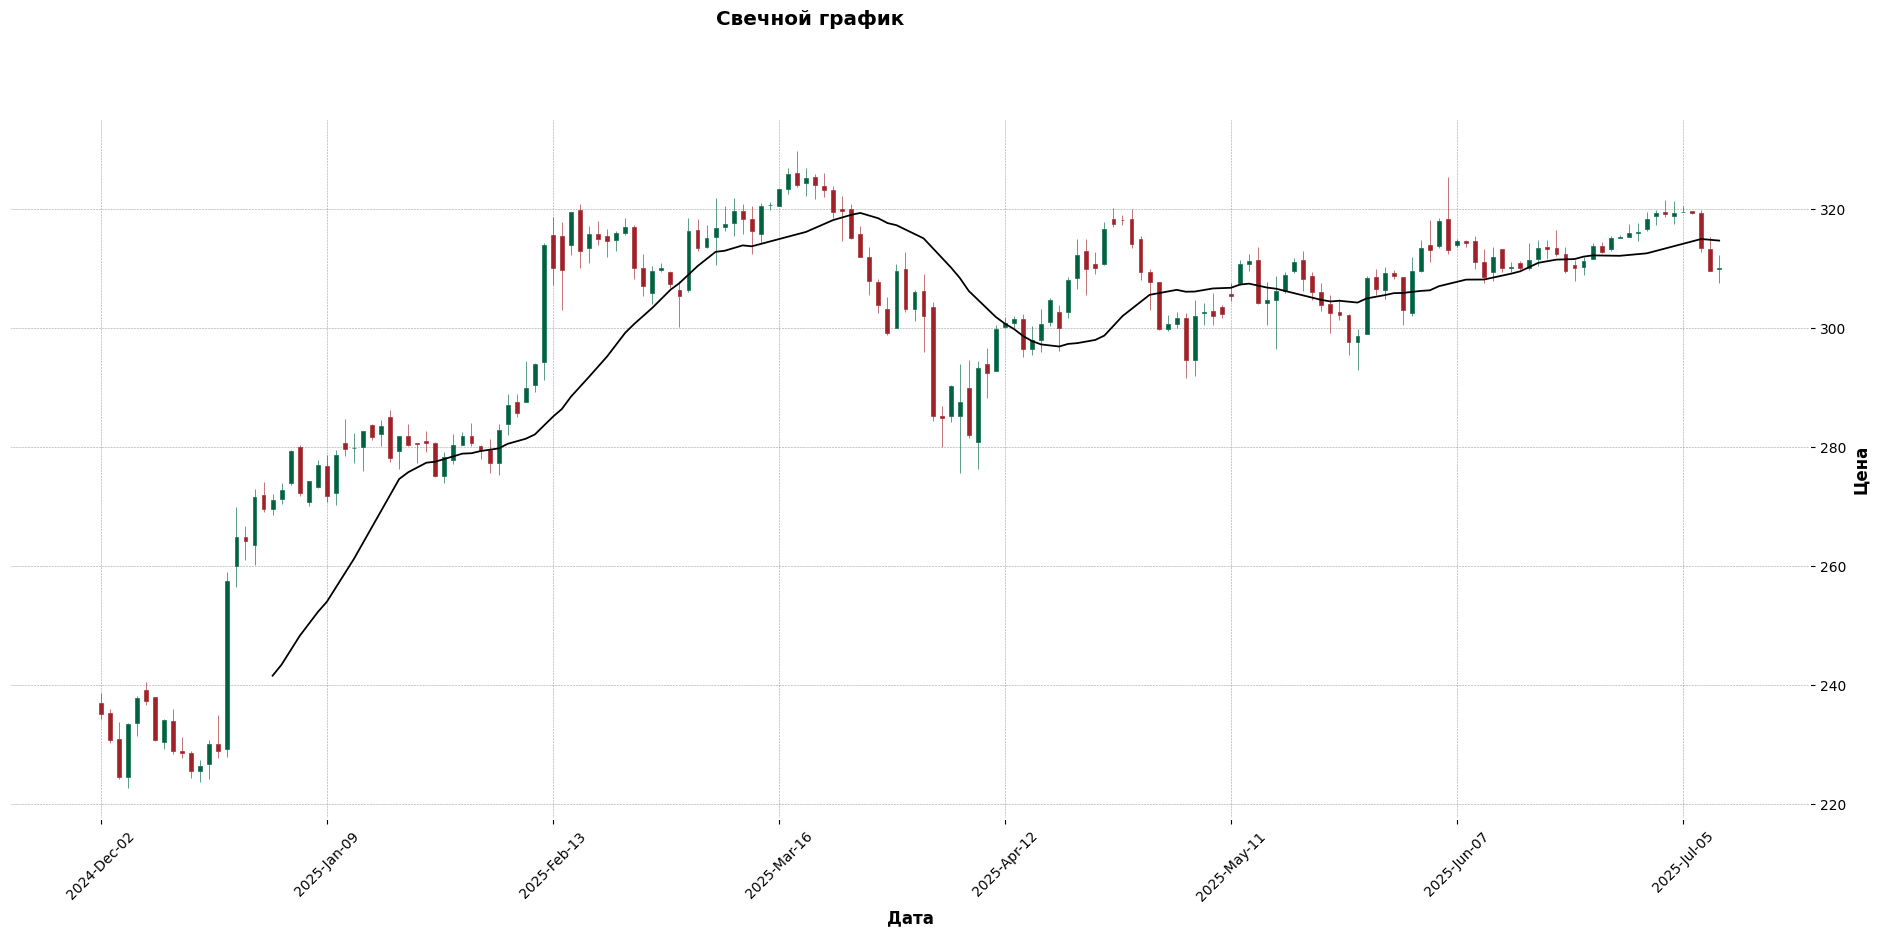

In [222]:
data['MAn'] = data['Close'].rolling(window=20).mean()
data['Trend'] = ['Uptrend' if data['Close'][i] > data['MAn'][i] else 'Downtrend' for i in range(len(data))]

MAn = mf.make_addplot(data['MAn'], color='black', markersize=100)

mf.plot(data, type='candle', style='charles', title='Свечной график',figsize=(25, 10), xlabel='Дата', ylabel='Цена', addplot=[MAn])

In [223]:
from scipy.signal import argrelextrema
import numpy as np

data['min'] = data.iloc[argrelextrema(data['Close'].values, np.less_equal, order=5)[0]]['Close']
data['max'] = data.iloc[argrelextrema(data['Close'].values, np.greater_equal, order=5)[0]]['Close']


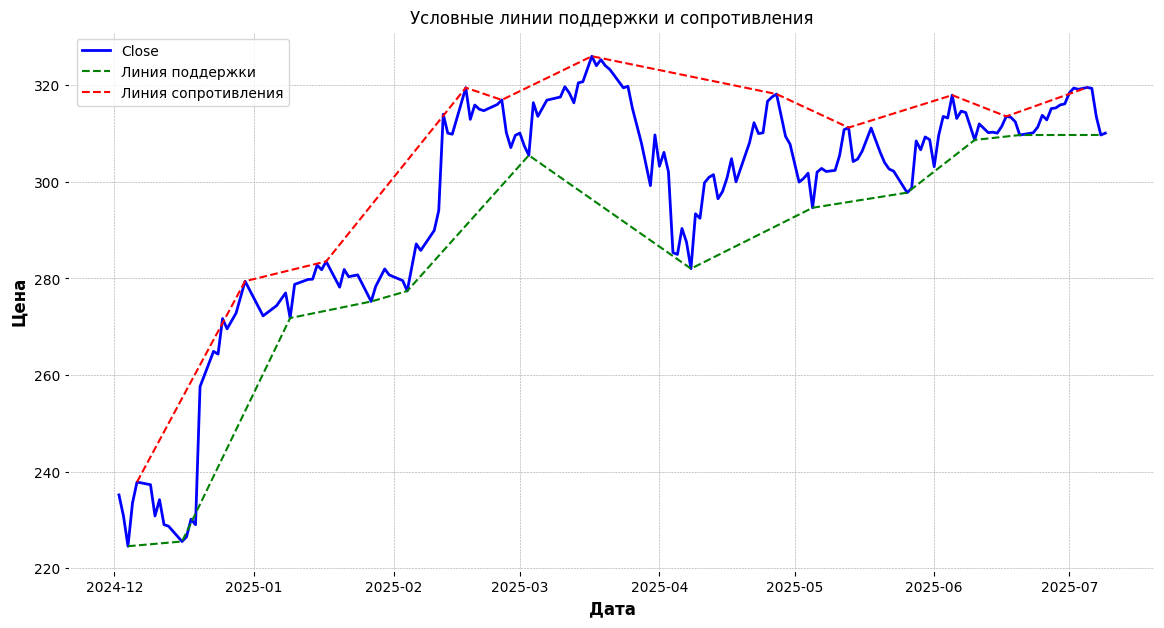

In [224]:


plt.figure(figsize=(14,7))

# График цены закрытия
plt.plot(data.index, data['Close'], label='Close', color='blue')

# Линия поддержки (интерполяция между локальными минимумами)
support_points = data['min'].dropna()
plt.plot(support_points.index, support_points.values, label='Линия поддержки', color='green', linestyle='--', linewidth=1.5)

# Линия сопротивления (интерполяция между локальными максимумами)
resistance_points = data['max'].dropna()
plt.plot(resistance_points.index, resistance_points.values, label='Линия сопротивления', color='red', linestyle='--', linewidth=1.5)

plt.title('Условные линии поддержки и сопротивления')
plt.xlabel('Дата')
plt.ylabel('Цена')
plt.legend()
plt.grid(True)
plt.show()

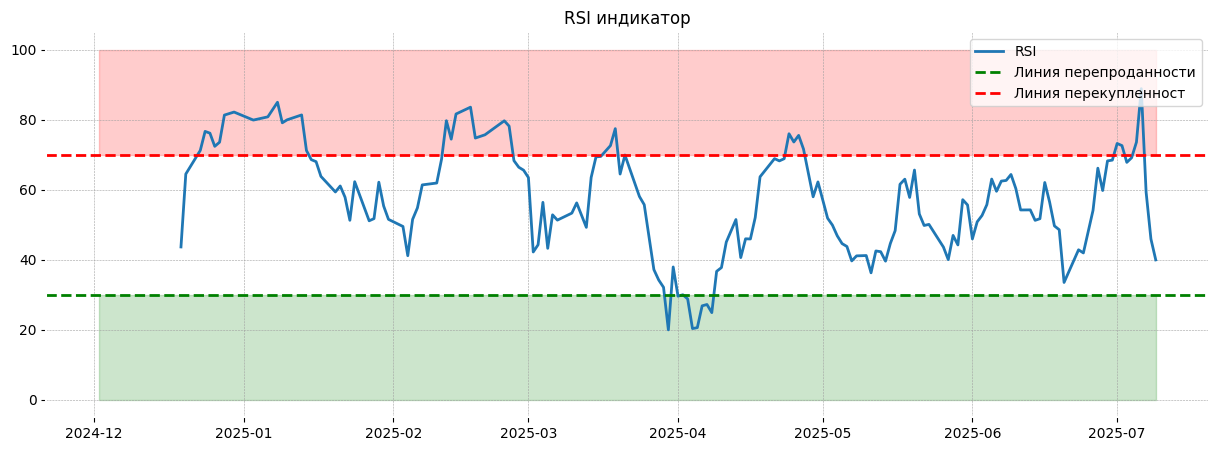

In [225]:
def RSI(series, period=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

data['RSI'] = RSI(data['Close'])

plt.figure(figsize=(15,5))
plt.plot(data['RSI'], label='RSI')       # график RSI
plt.axhline(30, color='green', linestyle='--', label='Линия перепроданности')  # линия перепроданности
plt.axhline(70, color='red', linestyle='--', label='Линия перекупленност')  # линия перекупленности
plt.fill_between(data.index, 70, 100, color='red', alpha=0.2)  # зона перекупленности
plt.fill_between(data.index, 0, 30, color='green', alpha=0.2) 
plt.title('RSI индикатор')
plt.legend(loc=1)
plt.show()

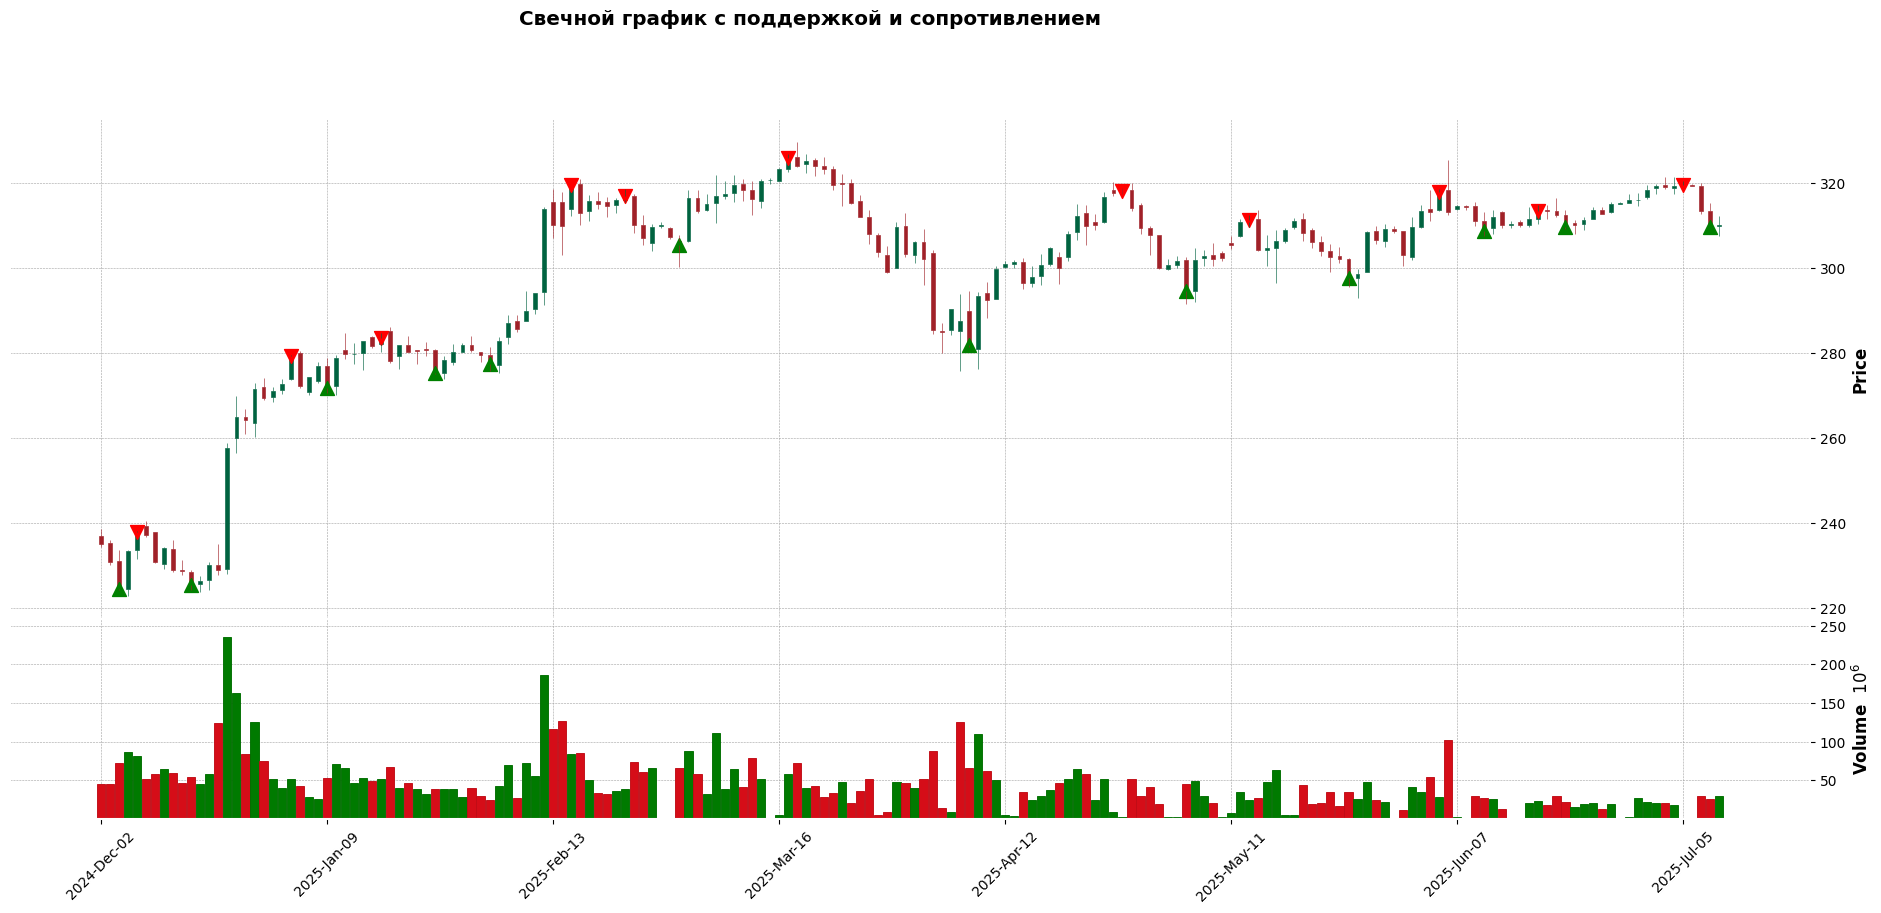

In [226]:
support = mf.make_addplot(data['min'], type='scatter', marker='^', color='green', markersize=100)
resistance = mf.make_addplot(data['max'], type='scatter', marker='v', color='red', markersize=100)

# Строим свечной график с добавленными линиями
mf.plot(
    data,
    type='candle',
    style='charles',
    title='Свечной график с поддержкой и сопротивлением',
    figsize=(25, 10),
    addplot=[support, resistance],
    volume=True
)